# INSTALL PACKET



In [3]:
# install the required packages for map
!pip install cartopy folium
!pip install openpyxl
!pip install Pillow
!pip install mplcursors
!pip install plotly

# IMPORT LIBRARY

In [4]:
##-- library --##

import sys
import pandas as pd
import numpy as np
import IPython
from IPython.display import display, Markdown, Latex, HTML, IFrame, JSON, Code, Image, YouTubeVideo, clear_output
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from PIL import Image
from google.colab import drive
from pathlib import WindowsPath
import matplotlib.patches as patches
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import requests
from io import BytesIO
import warnings
import seaborn as sns
sns.set_theme()
import matplotlib.colors as mcolors
import mplcursors
import plotly.graph_objects as go

# LOAD DATA

In [6]:
# Load datasets from Github :

# Raw file #

url1 = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/DATA_Earthquake_Master.xlsx"
url2 = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/ActiveFault-Plates.xlsx"
url3 = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/disaster_extracted.xlsx"

df_eq = pd.read_excel(url1 ,engine="openpyxl")
df = pd.read_excel(url1 ,engine="openpyxl")
df_pl = pd.read_excel(url2 , sheet_name="73 sensors EQ",engine="openpyxl")
df_dis = pd.read_excel(url3,sheet_name="Disaster_Extracted" ,engine="openpyxl")


# Pic #

url_img = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/Wiki_Earth_plates.png"
response = requests.get(url_img)
img = Image.open(BytesIO(response.content))


url_img1 = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/IndianPlate.png"
response = requests.get(url_img1)
img1 = Image.open(BytesIO(response.content))


url_img2 = "https://raw.githubusercontent.com/siriwatsc-debug/ProjectDADS5001/main/Thai_Fault_EU_Indian_plate.png"
response = requests.get(url_img2)
img2 = Image.open(BytesIO(response.content))


url_img3 = "https://raw.githubusercontent.com/siriwatsc-debug/ProjectDADS5001/main/Himalaya.gif"
response = requests.get(url_img3)
img3 = Image.open(BytesIO(response.content))



df_eq = df_eq.rename(columns={'No.':'no', 'REF. ID':'refid', 'DATE-TIME UTC':'dtutc','DATE_THAI':'date','YEAR':'year', 'MONTH' : 'month', 'DAY' : 'day',
                              'TIME THAI':'time', 'LAT.':'lat', 'LONG.':'long','MAG.':'mag',
                              'DEPTH.':'depth', 'PHASE.':'phase', 'REGION_NANE_THAI':'region_th','SUB_DISTINCT':'subdistrict', 'DISTINCT':'district',
                              'PROVINCE':'province', 'COUNTRY':'country', 'REGION':'region'}) # default: inplace=False

df = df.rename(columns={'No.':'no', 'REF. ID':'refid', 'DATE-TIME UTC':'dtutc','DATE_THAI':'date','YEAR':'year', 'MONTH' : 'month', 'DAY' : 'day',
                              'TIME THAI':'time', 'LAT.':'lat', 'LONG.':'long','MAG.':'mag',
                              'DEPTH.':'depth', 'PHASE.':'phase', 'REGION_NANE_THAI':'region_th','SUB_DISTINCT':'subdistrict', 'DISTINCT':'district',
                              'PROVINCE':'province', 'COUNTRY':'v', 'REGION':'region'}) # default: inplace=False

df2 = df_dis.rename(columns={'DisNo.':'DisNo', 'Classification Key':'classKey',
                             'Disaster Type':'distype','Disaster Subtype':'dissubtype',
                             'Country':'country', 'Subregion':'subreg', 'Associated Types':'assotype',
                             'Magnitude':'mag', 'Latitude':'lat', 'Longitude':'long',  'Start Year':'styear',
                             'Start Month':'stmonth',
                             'Start Day':'stday', 'End Year':'endyear','End Month':'endmonth', 'End Day':'endday',
                             'Total Deaths':'totaldeaths', 'No. Injured':'injure','No. Affected':'affected',
                             'No. Homeless':'homeless', 'Total Affected':'totalaffected',
                             'Reconstruction Costs (\'000 US$)':'recon_cost',
                             'Reconstruction Costs, Adjusted (\'000 US$)':'recon_cost_adj',
                             'Insured Damage (\'000 US$)':'insuredamage',
                             'Insured Damage, Adjusted (\'000 US$)':'insuredamage_adj',
                             'Total Damage (\'000 US$)':'totaldamage',
                             'Total Damage, Adjusted (\'000 US$)' : 'totaldamage_adj',
                             'Entry Date':'entrydate', 'Last Update':'lastupdate'}) # default: inplace=False



# PATH I

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Do

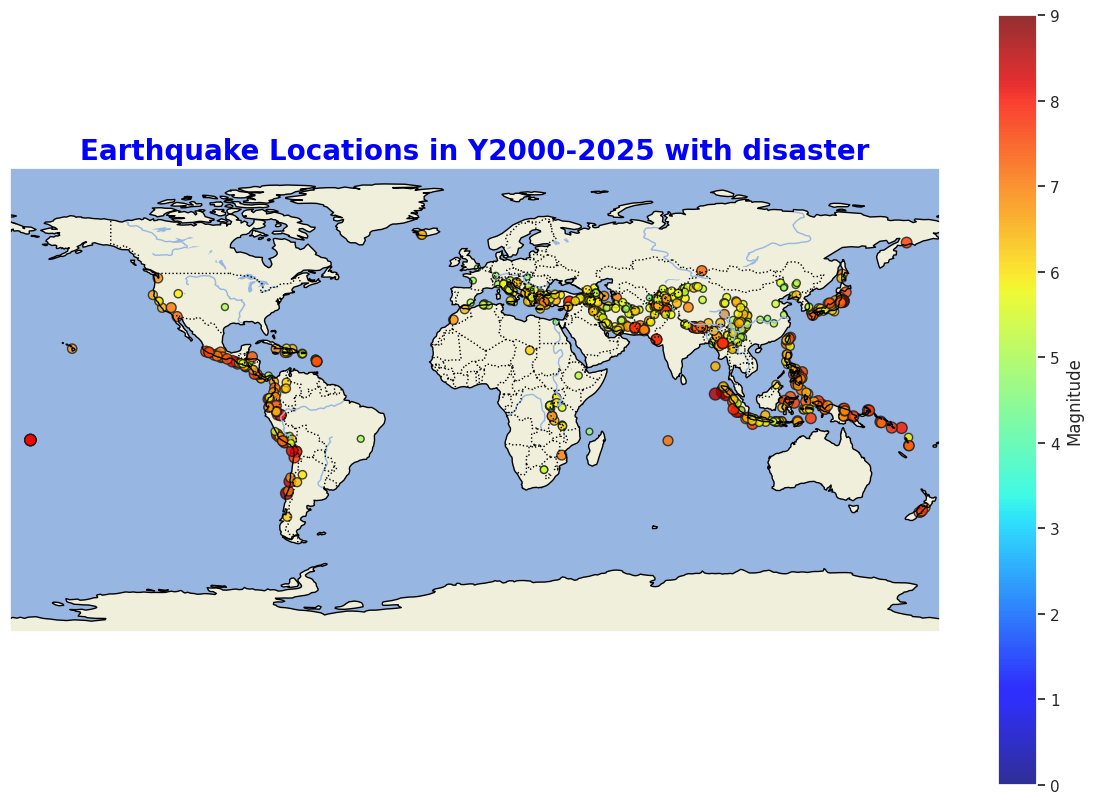

# Global : Earthquake with disasters
## <font color=Green>ที่มา :  https://www.emdat.be </font>



In [7]:
# Overall Earth Quake Global with Disaster

# Set Data Frame : Disaster
#df = df_dis
#print(df.columns)



# column: 'Latitude', 'Longitude', 'Magnitude'
lat = df2["lat"]
lon = df2["long"]
mag = df2["mag"]

# Plot map
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add borders
#ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Set Frame to plot for Global
ax.set_extent([-180, 180, -180, 180], crs=ccrs.PlateCarree())

# plot EQ location by lat and long
sc = ax.scatter(
    lon, lat,
    c=mag, s=mag**2,   # ขนาดจุด ∝ magnitude
    cmap="jet", alpha=0.8,
    vmin=0, vmax=9.0,
    edgecolor="k", transform=ccrs.PlateCarree()
)

# colorbar
plt.colorbar(sc, ax=ax, label="Magnitude")
#plt.text(-10, -10, 'Earthquake Locations with Magnitude (2000-2025) with disaster', fontsize = 15, fontweight='bold', color='blue')
plt.title("Earthquake Locations in Y2000-2025 with disaster",fontsize = 20, fontweight='bold', color='blue', loc = 'center')
plt.show()


s = """# Global : Earthquake with disasters
## <font color=Green>ที่มา :  https://www.emdat.be </font>

"""

warnings.filterwarnings("ignore", category=UserWarning)

display( Markdown(s) )

# PATH II

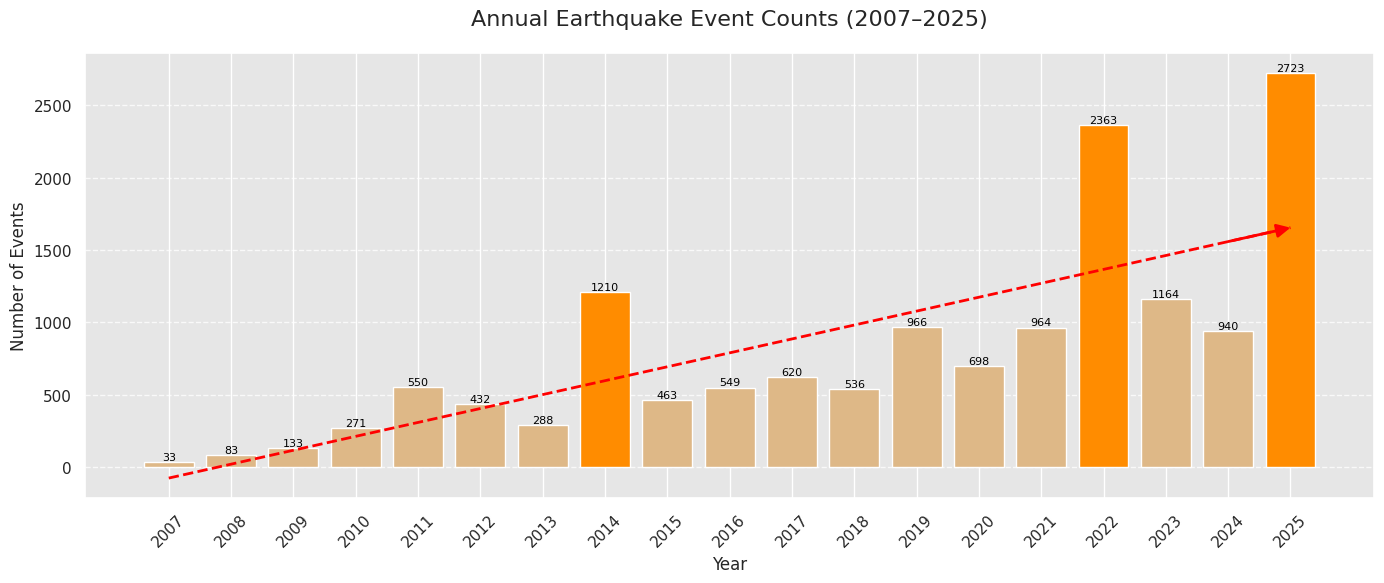

In [10]:
# เตรียมข้อมูล
year_counts = df['year'].astype(int).value_counts().sort_index()
years = year_counts.index.values
counts = year_counts.values
years_str = years.astype(str)

# ปีที่ต้องการเน้น (สีแท่ง)
highlight_years = ['2014', '2022', '2025']
bar_colors = ['darkorange' if str(y) in highlight_years else 'burlywood' for y in years]

# สร้าง Figure และ Axes
fig, ax = plt.subplots(figsize=(14, 6))

# พล็อตกราฟแท่ง
bars = ax.bar(years, counts, color=bar_colors, width=0.8, label='Events')

# เส้นแนวโน้มแบบ linear regression
z = np.polyfit(years, counts, 1)
p = np.poly1d(z)
trend_line, = ax.plot(years, p(years), color='red', linestyle='--', linewidth=2, label='Trend')

# ลูกศรปลายเดียวชี้ปลายสุดของ trend line
start = (years[-2], p(years[-2]))  # จุดเริ่มก่อนปลาย
end = (years[-1], p(years[-1]))    # ปลายสุดของเส้น
arrow = FancyArrowPatch(
    start, end,
    arrowstyle='-|>',   # ปลายลูกศรเท่านั้น
    color='red',
    mutation_scale=20,
    lw=2,
    shrinkA=0,          # จุดเริ่มไม่มีหัวลูกศร
    shrinkB=0           # จุดปลายหัวลูกศรเต็ม
)
ax.add_patch(arrow)

# เพิ่มตัวเลขบนยอดแท่ง
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{int(height)}',
        ha='center', va='bottom',
        fontsize=8, color='black'
    )

# ปรับแกน x ให้แสดงเป็นปี (string)
ax.set_xticks(years)
ax.set_xticklabels(years_str, rotation=45)

# พื้นหลังและกริด
ax.set_facecolor('#e6e6e6')
ax.grid(True, color='white', linestyle='--', linewidth=1, axis='y', alpha=0.8)

# ปรับข้อความ
ax.set_title('Annual Earthquake Event Counts (2007–2025)', fontsize=16, pad=20)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')


plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


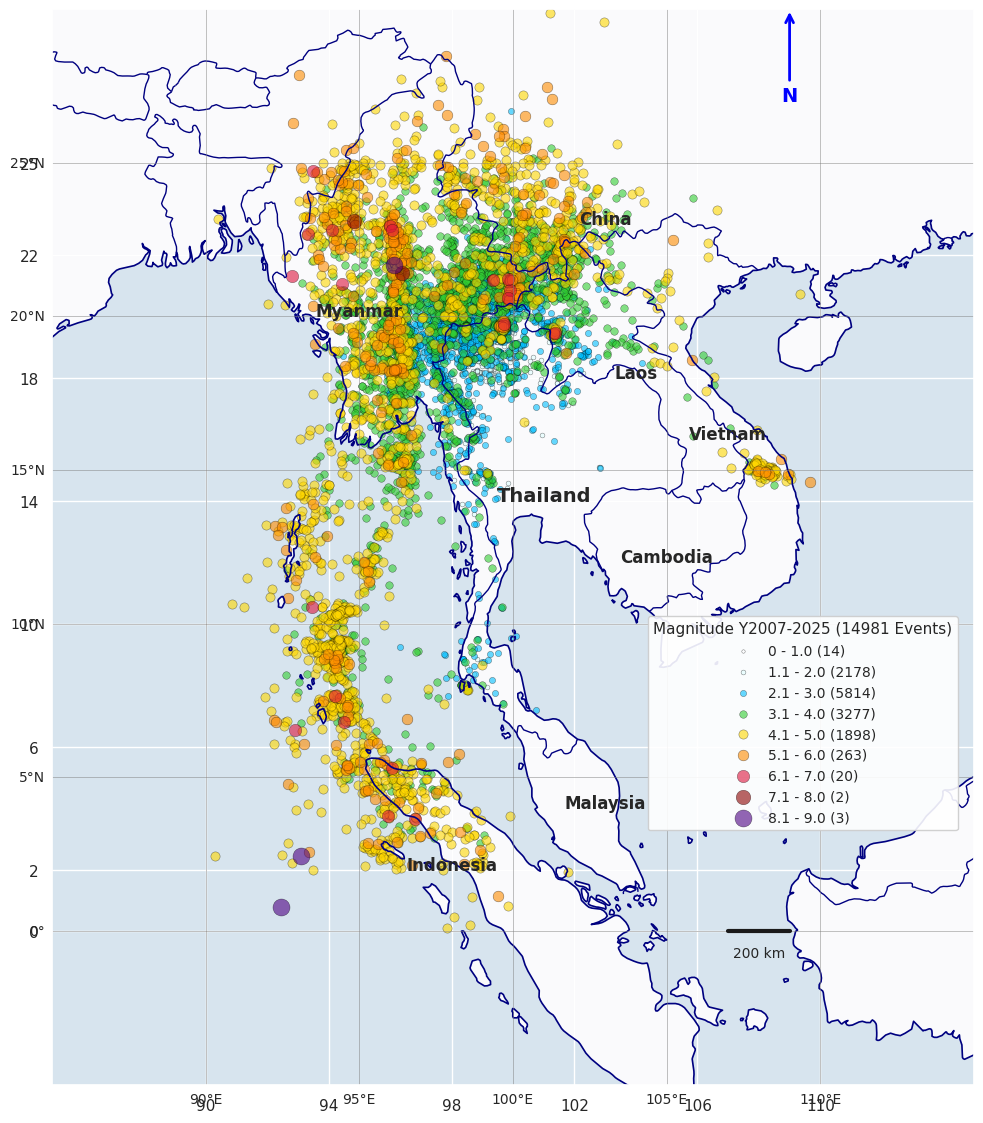

# Local : Earthquake in Thailand and nearby
## <font color=Green>ที่มา : กองเฝ้าระวังแผ่นดินไหว (https://earthquake.tmd.go.th)</font>



In [11]:
# Plot : Overall Magnitude by range VS Areas around Thailand

# Load data EQ
df = df_eq.copy()

# Pick : lat, long and magnitude
lat_all = df["lat"].values
lon_all = df["long"].values
mag_all = df["mag"].values

# Frame position in Map (SEA region)
mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
lat_filtered = lat_all[mask]
lon_filtered = lon_all[mask]
mag_filtered = mag_all[mask]

# Create Map
fig = plt.figure(figsize=(10, 15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([85, 115, -5, 30], crs=ccrs.PlateCarree())

# Add Geo features
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

# Create colormap and size mapping
colors_map = {
    (0, 1.0):   ('white', 3),           # ขาว
    (1.1, 2.0): ('lightcyan', 6),       # ฟ้าอ่อนมาก
    (2.1, 3.0): ('deepskyblue', 10),    # ฟ้า
    (3.1, 4.0): ('limegreen', 15),      # เขียว
    (4.1, 5.0): ('gold', 22),           # ทอง
    (5.1, 6.0): ('darkorange', 30),     # ส้มเข้ม
    (6.1, 7.0): ('crimson', 40),        # แดงเข้ม
    (7.1, 8.0): ('darkred', 55),        # แดงเข้มมาก
    (8.1, 9.0): ('indigo', 75)          # น้ำเงินเข้ม
}

# Put EQ Mag in each lat and long
for (min_mag, max_mag), (color, size) in colors_map.items():
    mask_mag = (mag_filtered >= min_mag) & (mag_filtered < max_mag)
    if np.any(mask_mag):
        count = np.sum(mask_mag)
        ax.scatter(lon_filtered[mask_mag], lat_filtered[mask_mag],
                   c=color, s=size*2, alpha=0.6,
                   edgecolor='black', linewidth=0.3,
                   transform=ccrs.PlateCarree(),
                   label=f'{min_mag} - {max_mag} ({count})')

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
ax.set_xticks([90, 94, 98, 102, 106, 110], crs=ccrs.PlateCarree())
ax.set_yticks([0, 2, 6, 10, 14, 18, 22, 25], crs=ccrs.PlateCarree())

# Label Country
ax.text(95, 20, 'Myanmar', fontsize=12, ha='center', fontweight='bold')
ax.text(103, 23, 'China', fontsize=12, ha='center', fontweight='bold')
ax.text(104, 18, 'Laos', fontsize=12, ha='center', fontweight='bold')
ax.text(101, 14, 'Thailand', fontsize=14, ha='center', fontweight='bold')
ax.text(107, 16, 'Vietnam', fontsize=12, ha='center', fontweight='bold')
ax.text(105, 12, 'Cambodia', fontsize=12, ha='center', fontweight='bold')
ax.text(103, 4, 'Malaysia', fontsize=12, ha='center', fontweight='bold')
ax.text(98, 2, 'Indonesia', fontsize=12, ha='center', fontweight='bold')

# Legend
legend = ax.legend(title=f'Magnitude Y2007-2025 ({len(mag_filtered)} Events)',
                   loc='lower right', fontsize=10, title_fontsize=11,
                   bbox_to_anchor=(0.99, 0.23))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Scale bar
scale_lon = 107
scale_lat = 0
ax.plot([scale_lon, scale_lon+2], [scale_lat, scale_lat], 'k-', lw=3,
        transform=ccrs.PlateCarree())
ax.text(scale_lon+1, scale_lat-0.5, '200 km',
        ha='center', va='top', fontsize=10,
        transform=ccrs.PlateCarree())

# North arrow
ax.annotate('N', xy=(109, 30), xytext=(109, 27),
            arrowprops=dict(arrowstyle='->', lw=2, color ='blue'),
            fontsize=14, ha='center', fontweight='bold', color ='blue',
            transform=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

s = """# Local : Earthquake in Thailand and nearby
## <font color=Green>ที่มา : กองเฝ้าระวังแผ่นดินไหว (https://earthquake.tmd.go.th)</font>

"""

warnings.filterwarnings("ignore", category=UserWarning)

display( Markdown(s) )

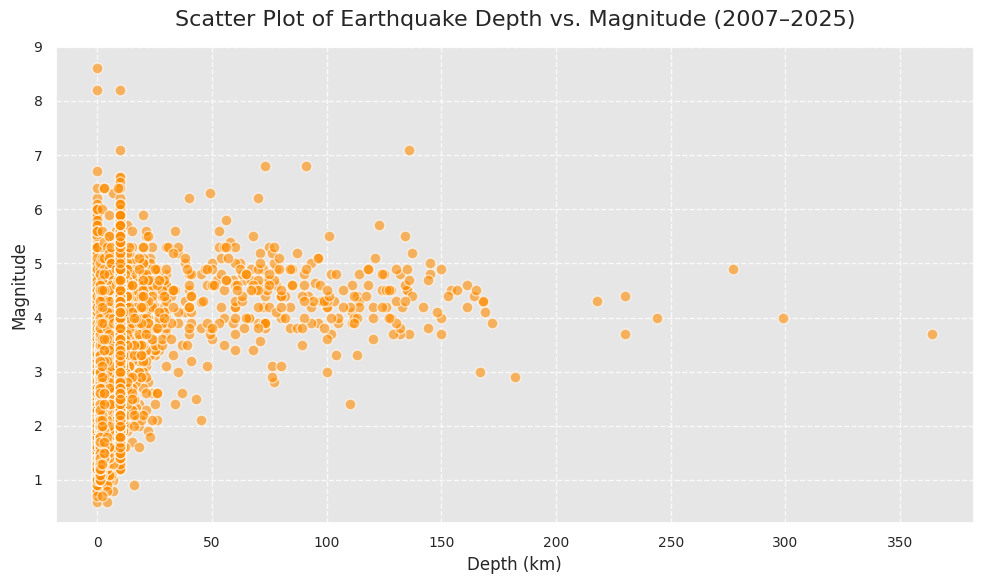

In [13]:
import matplotlib.pyplot as plt

# กรองเฉพาะข้อมูลที่มี DEPTH และ MAG
df = df.dropna(subset=['depth', 'mag'])
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df = df.dropna(subset=['depth', 'mag'])

# สร้าง Figure และ Axes
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#e6e6e6')  # พื้นหลังสีเทาอ่อน

# พล็อต Scatter Plot
scatter = ax.scatter(df['depth'], df['mag'],
                     alpha=0.6, c='darkorange', edgecolors='white', s=60)

# ปรับแต่งแกนและข้อความ
ax.set_title('Scatter Plot of Earthquake Depth vs. Magnitude (2007–2025)', fontsize=16, pad=15)
ax.set_xlabel('Depth (km)', fontsize=12)
ax.set_ylabel('Magnitude', fontsize=12)

# เส้นกริดแบบขีดสีขาว
ax.grid(True, color='white', linestyle='--', linewidth=1, alpha=0.8)

# ปรับขนาดตัวอักษรแกน
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


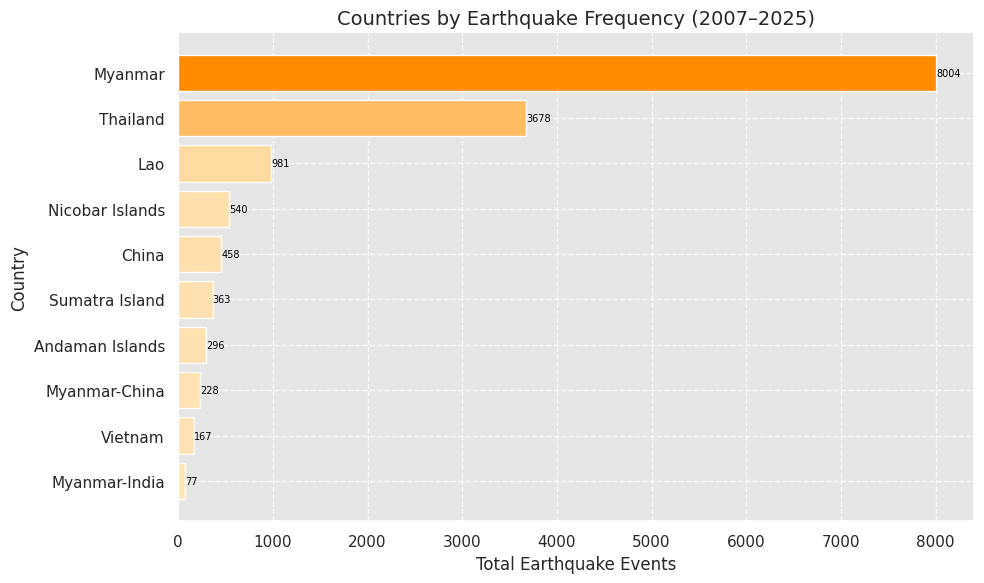

In [14]:


# แปลง YEAR เป็นตัวเลข แล้วกรองค่า missing
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year', 'country', 'lat', 'long'])

# กรองเฉพาะเหตุการณ์ในพิกัด SEA
df_sea = df[(df['lat'] >= 0) & (df['lat'] <= 30) & (df['long'] >= 90) & (df['long'] <= 115)]

# นับจำนวนเหตุการณ์ต่อประเทศในพื้นที่ SEA
country_counts_sea = df_sea['country'].value_counts().nlargest(10).sort_values()

# สร้าง colormap ไล่เฉดสีจากสีอ่อนถึงสีเข้ม
cmap = mcolors.LinearSegmentedColormap.from_list("orange_gradient", ["moccasin", "darkorange"])
norm = plt.Normalize(country_counts_sea.min(), country_counts_sea.max())
colors = cmap(norm(country_counts_sea.values))

# สร้างกราฟด้วย plt.subplots() เพื่อควบคุมพื้นหลัง
fig, ax = plt.subplots(figsize=(10, 6))

# วาดกราฟแท่งแนวนอน
bars = ax.barh(country_counts_sea.index, country_counts_sea.values, color=colors)

# ตั้งค่าพื้นหลังสีเทาอ่อน
ax.set_facecolor('#e6e6e6')

# เพิ่มตัวเลขที่ปลายแท่ง
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height() / 2,
            f'{int(width)}', va='center', fontsize=7, color='black')

# ปรับข้อความและกริด
ax.set_title('Countries by Earthquake Frequency (2007–2025)', fontsize=14)
ax.set_xlabel('Total Earthquake Events')
ax.set_ylabel('Country')
ax.grid(True, color='white', linestyle='--', linewidth=1, axis='both', alpha=0.8)

plt.tight_layout()
plt.show()


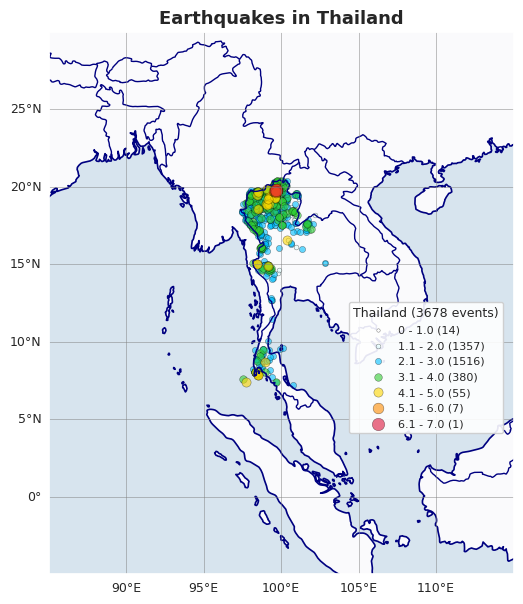

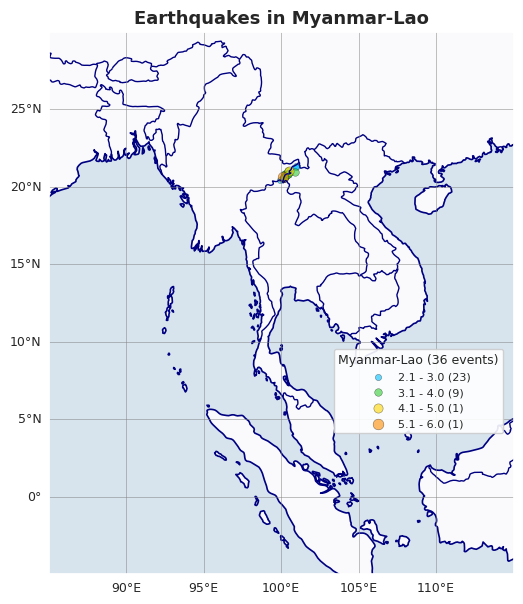

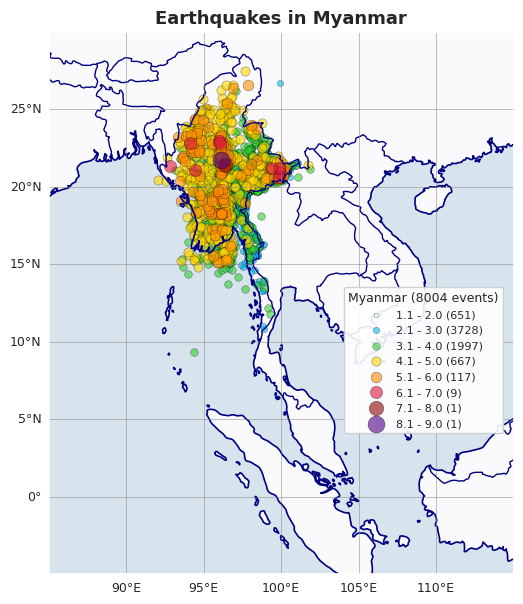

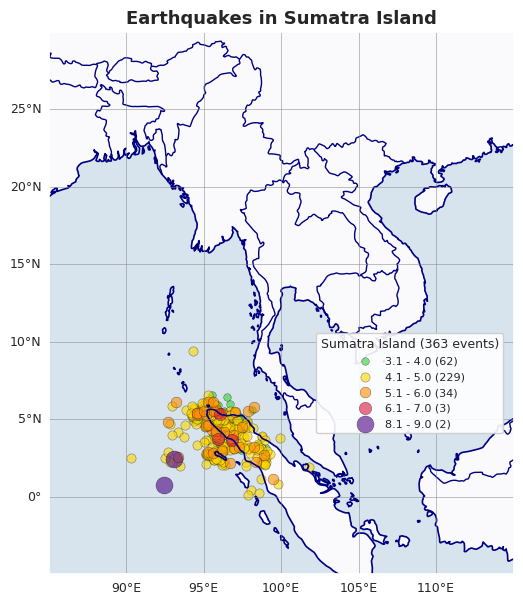

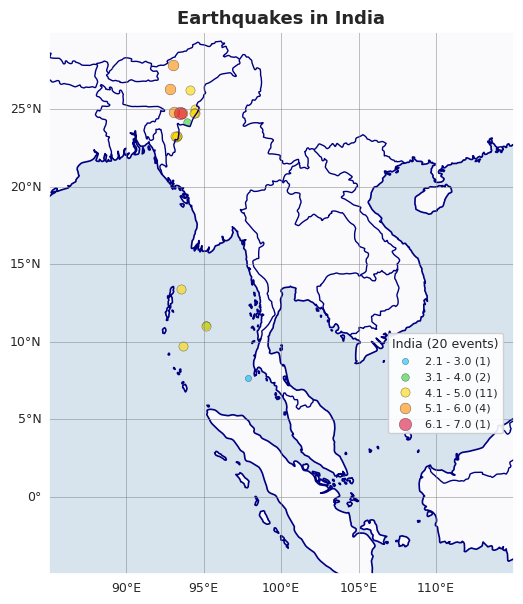

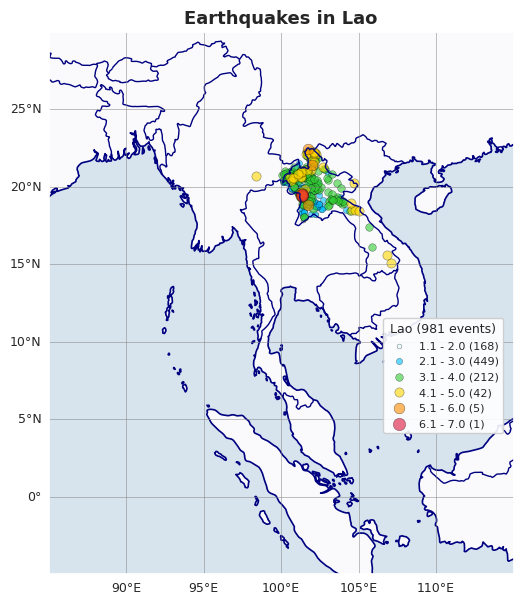

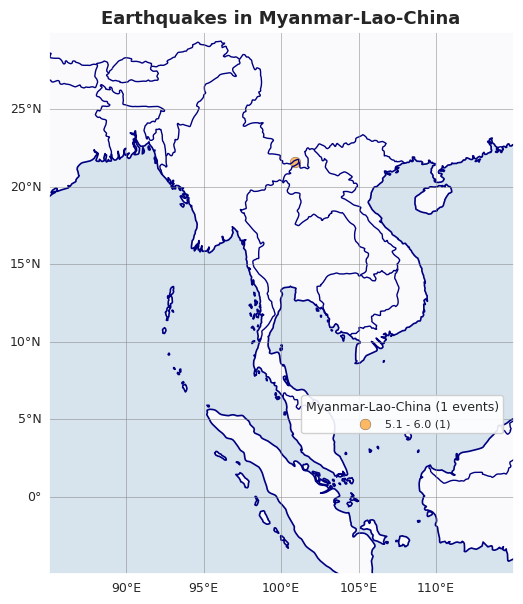

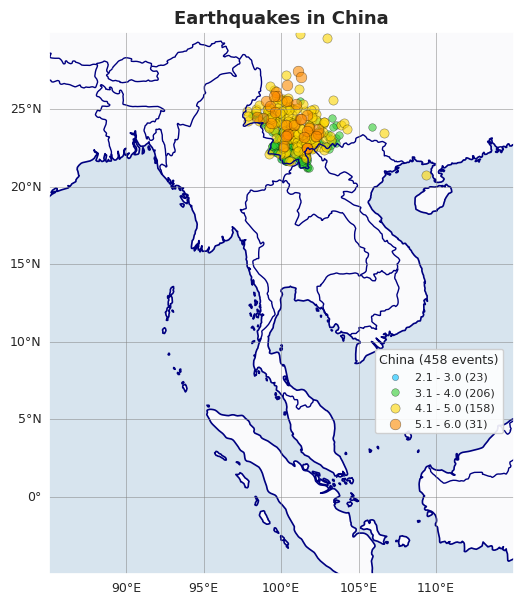

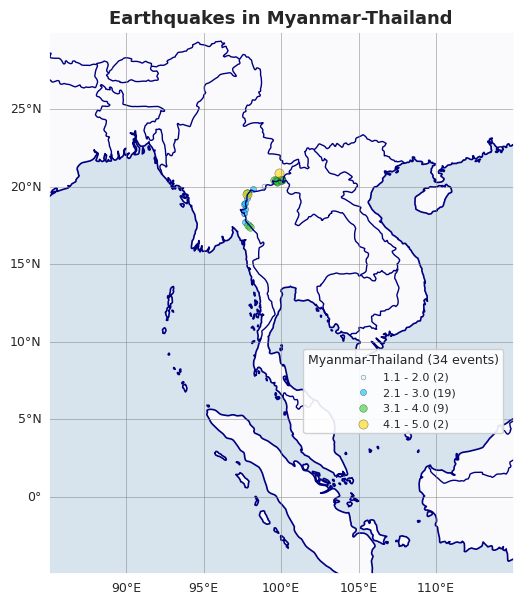

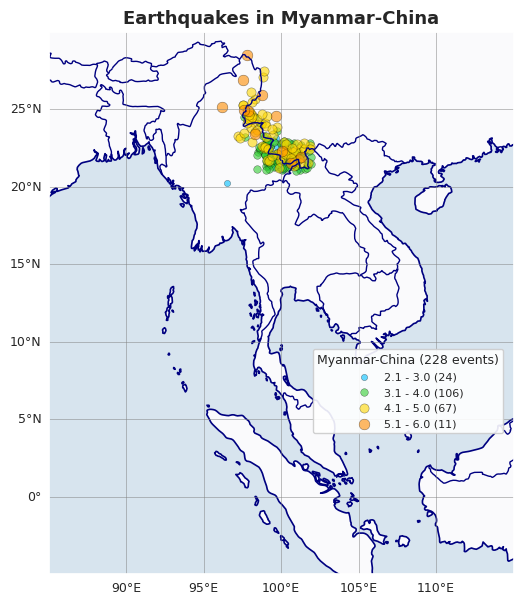

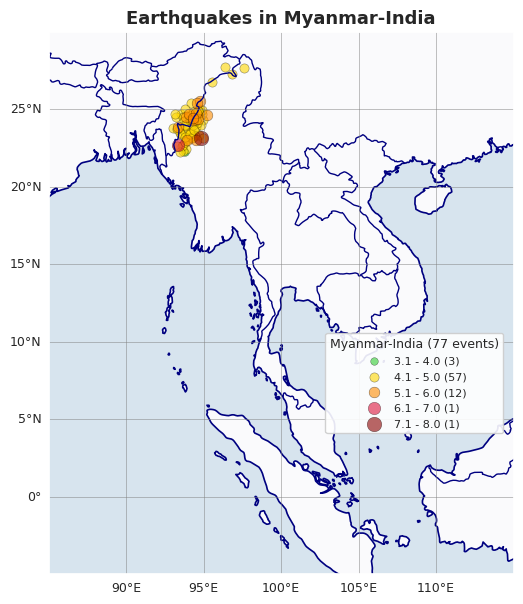

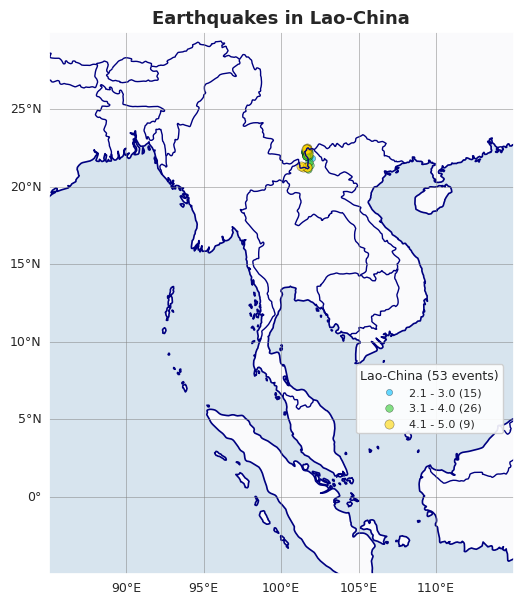

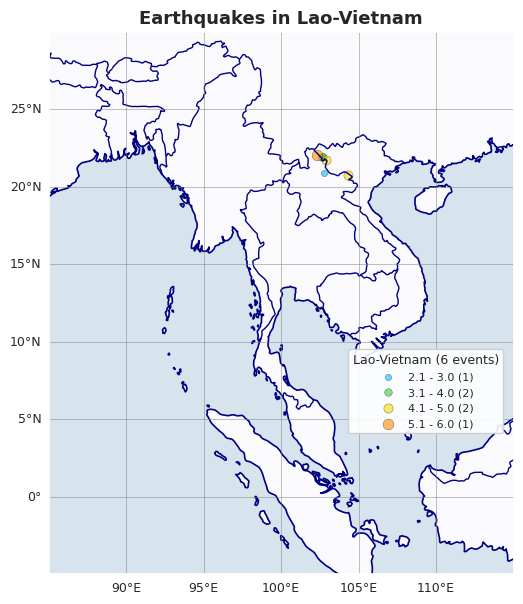

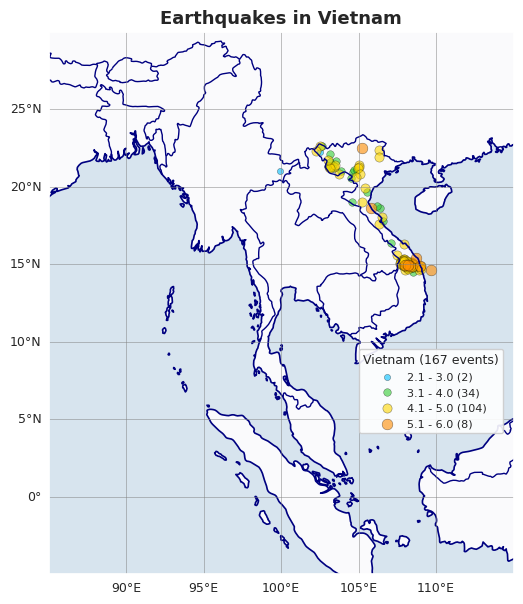

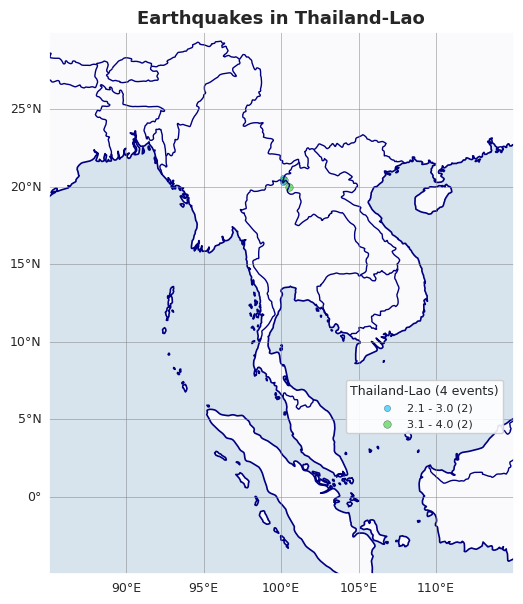

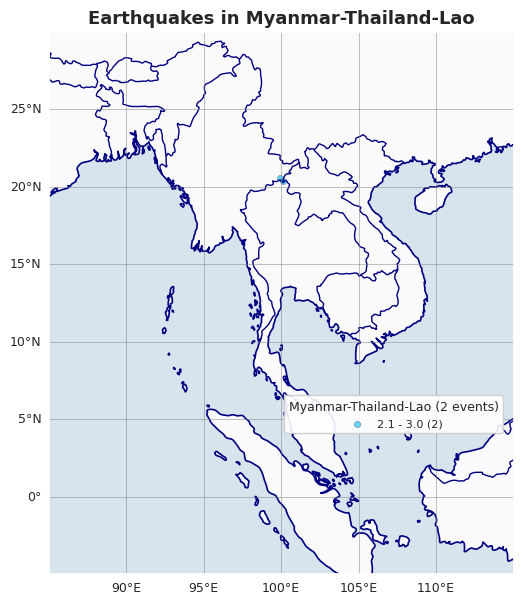

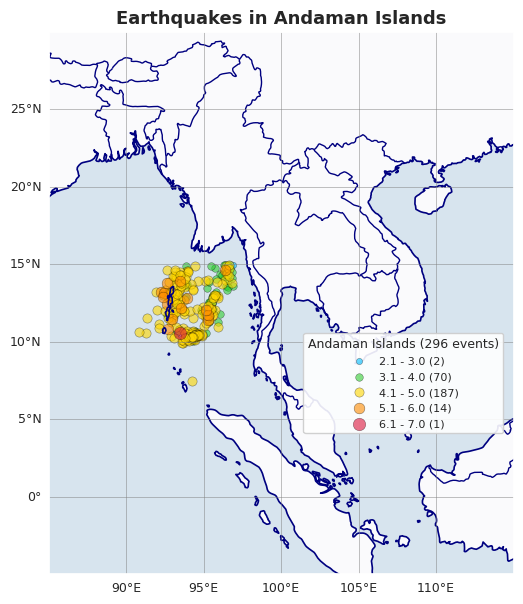

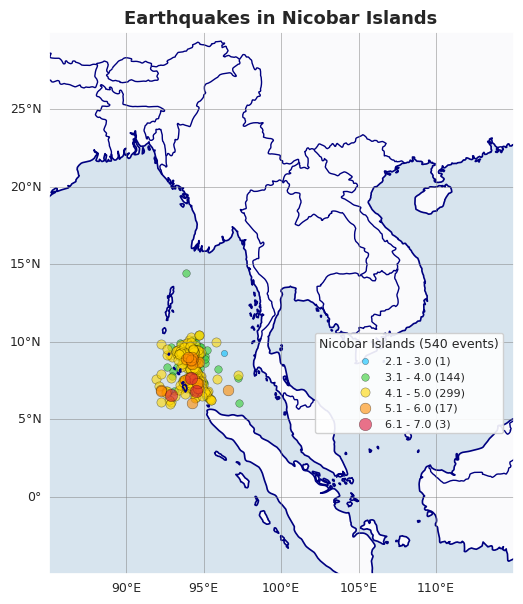

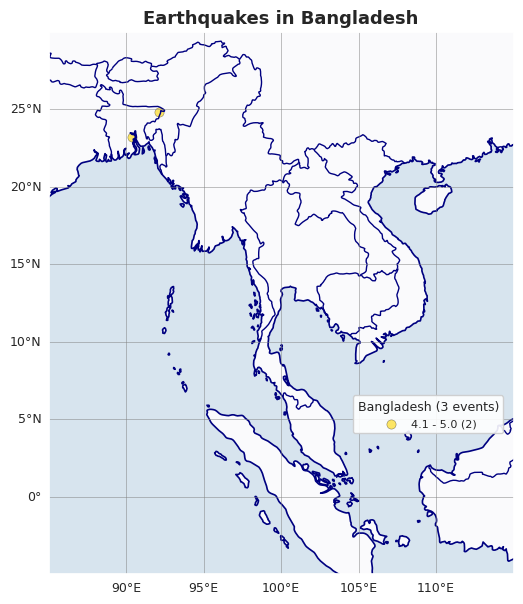

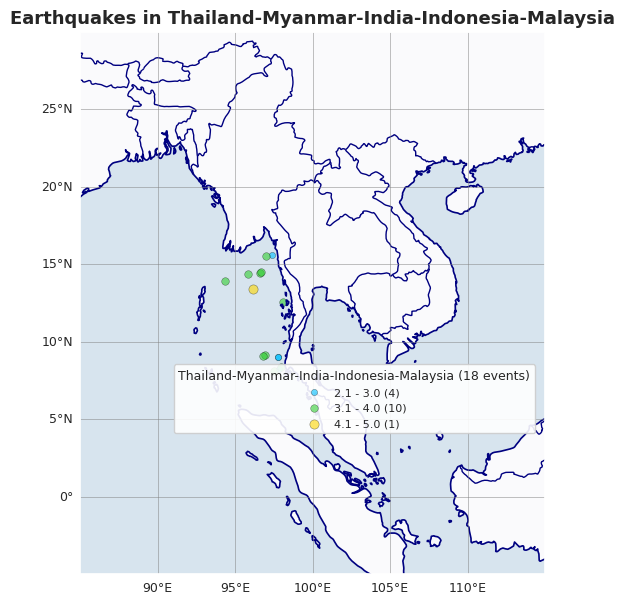

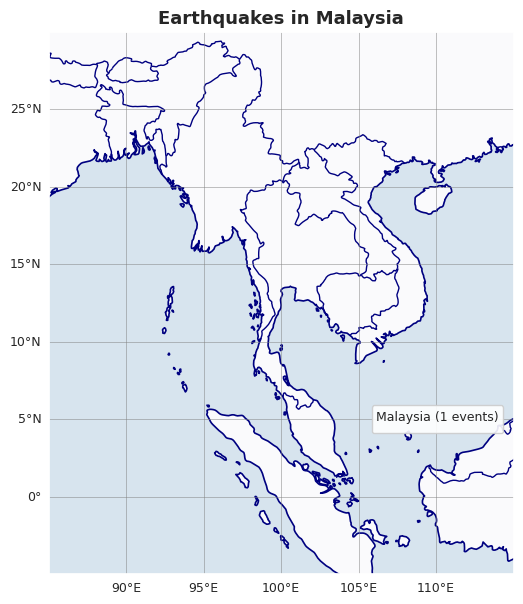

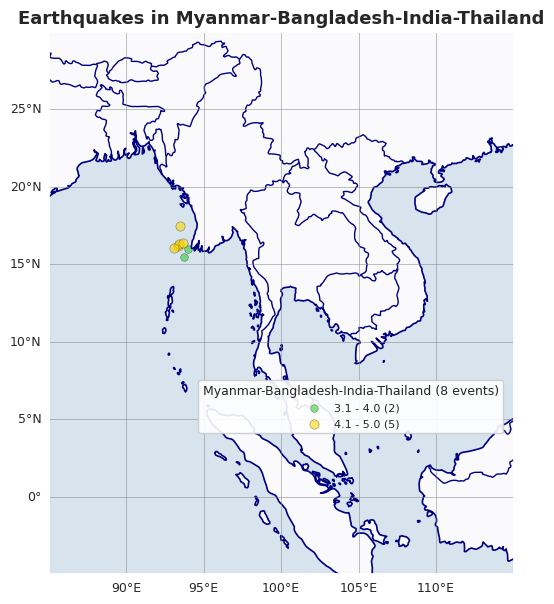

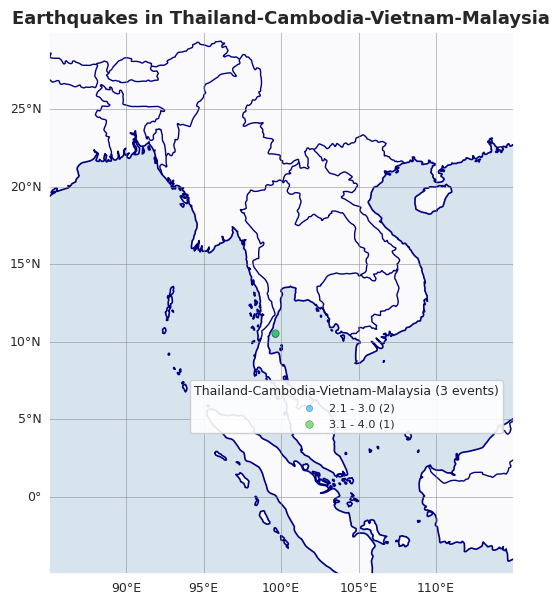

In [15]:
# Plot : Overall Magnitude by Country VS Areas around Thailand

df = df_eq.copy()
#df.info()

# === Drop NaN in Country ===
df = df_eq.dropna(subset=["country"])

# === Function plot per Country ===
def plot_country(country_name, df_country):
    lat_all = df_country["lat"].values
    lon_all = df_country["long"].values
    mag_all = df_country["mag"].values

    # Filter in SEA
    mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
    lat_filtered = lat_all[mask]
    lon_filtered = lon_all[mask]
    mag_filtered = mag_all[mask]

    # Create Map
    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    #ax.set_extent([95, 110, 0, 25], crs=ccrs.PlateCarree())

    ax.set_extent([85, 115, -5, 30], crs=ccrs.PlateCarree())

    # Add Geo features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
    ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # Colormap magnitude
    colors_map = {
        (0, 1.0):   ('white', 3),
        (1.1, 2.0): ('lightcyan', 6),
        (2.1, 3.0): ('deepskyblue', 10),
        (3.1, 4.0): ('limegreen', 15),
        (4.1, 5.0): ('gold', 22),
        (5.1, 6.0): ('darkorange', 30),
        (6.1, 7.0): ('crimson', 40),
        (7.1, 8.0): ('darkred', 55),
        (8.1, 9.0): ('indigo', 75)
    }

    # Scatter points
    for (min_mag, max_mag), (color, size) in colors_map.items():
        mask_mag = (mag_filtered >= min_mag) & (mag_filtered < max_mag)
        #print( len(mag_filtered))
        if np.any(mask_mag):
            count = np.sum(mask_mag)
            ax.scatter(lon_filtered[mask_mag], lat_filtered[mask_mag],
                       c=color, s=size*2, alpha=0.6,
                       edgecolor='black', linewidth=0.3,
                       transform=ccrs.PlateCarree(),
                       label=f'{min_mag} - {max_mag} ({count})')

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Legend
    legend = ax.legend(title=f'{country_name} ({len(mag_filtered)} events)',
                       loc='lower right', fontsize=8, title_fontsize=9,
                       bbox_to_anchor=(0.99, 0.25))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    ax.set_title(f"Earthquakes in {country_name}", fontsize=13, fontweight='bold')
    plt.show()


# === Loop plot per country ===
countries = df["country"].unique()

for country in countries:
    df_country = df[df["country"] == country]
    plot_country(country, df_country)


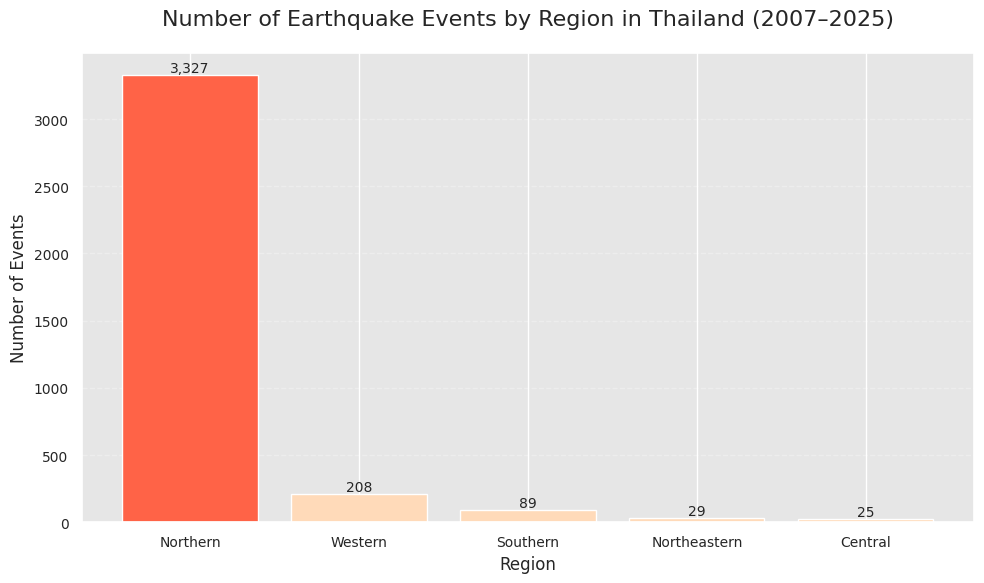

In [17]:


# เตรียมข้อมูล: นับจำนวนเหตุการณ์ต่อ REGION และเรียงจากมากไปน้อย
region_counts = df[df['country'].str.strip().str.lower() == 'thailand']['region'].value_counts().sort_values(ascending=False)

# กำหนดสี: ไฮไลต์ 'northern' ด้วยสี 'mediumorchid'
highlight_region = 'northern'
colors = ['tomato' if region.strip().lower() == highlight_region else 'peachpuff' for region in region_counts.index]

# สร้างกราฟ
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(region_counts.index, region_counts.values, color=colors)

# เพิ่มตัวเลขบนยอดแท่ง
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

# ปรับพื้นหลังและกริด
ax.set_facecolor('#e6e6e6')
ax.grid(True, axis='y', linestyle='--', color='white', alpha=0.3)

# ปรับข้อความ
ax.set_title('Number of Earthquake Events by Region in Thailand (2007–2025)', fontsize=16, pad=20)
ax.set_xlabel('Region')
ax.set_ylabel('Number of Events')
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()


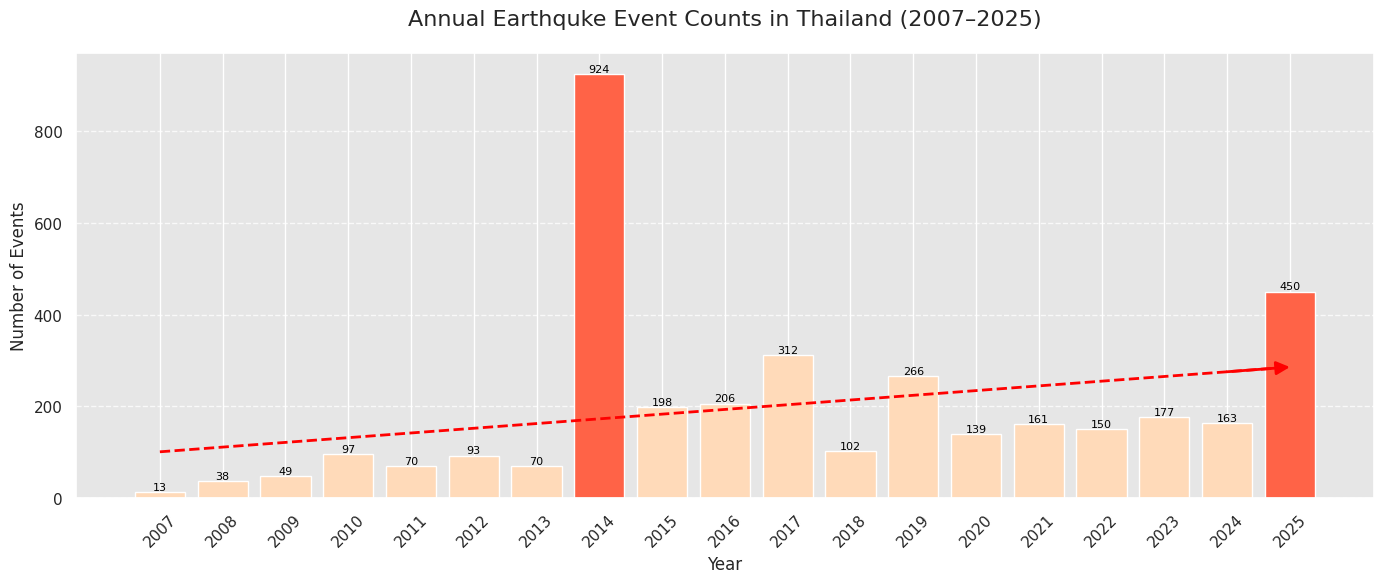

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# กรองข้อมูลเฉพาะประเทศไทย และแปลงปีเป็น int
df_th = df[df['country'].str.strip().str.lower() == 'thailand'].copy()
df_th['year'] = pd.to_numeric(df_th['year'], errors='coerce')
df_th = df_th.dropna(subset=['year'])
df_th['year'] = df_th['year'].astype(int)

# นับจำนวนเหตุการณ์ต่อปี
year_counts = df_th.groupby('year').size()
years = year_counts.index.values
counts = year_counts.values

# กำหนดปีที่ต้องการเน้น
highlight_years = [2014, 2025]
colors = ['tomato' if year in highlight_years else 'peachpuff' for year in years]

# สร้างกราฟ
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(years, counts, color=colors, width=0.8)

# เส้นแนวโน้มแบบ Linear Regression
z = np.polyfit(years, counts, 1)
p = np.poly1d(z)
ax.plot(years, p(years), color='red', linestyle='--', linewidth=2, label='Trend')

# เพิ่มลูกศรปลายเดียวที่ปลายเส้นแนวโน้ม
arrow = FancyArrowPatch(
    (years[-2], p(years[-2])), (years[-1], p(years[-1])),
    arrowstyle='-|>', color='red', mutation_scale=20, lw=2,
    shrinkA=0, shrinkB=0
)
ax.add_patch(arrow)

# เพิ่มตัวเลขบนยอดแท่ง
for bar, year in zip(bars, years):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{int(height)}',
        ha='center', va='bottom',
        fontsize=8,
        color='black'
    )

# ปรับแต่งกราฟ
ax.set_facecolor('#e6e6e6')
ax.set_title('Annual Earthquke Event Counts in Thailand (2007–2025)', fontsize=16, pad=20)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Events')
ax.set_xticks(years)
ax.set_xticklabels(years.astype(str), rotation=45)
ax.grid(True, color='white', linestyle='--', linewidth=1, axis='y', alpha=0.8)

plt.tight_layout()
plt.show()


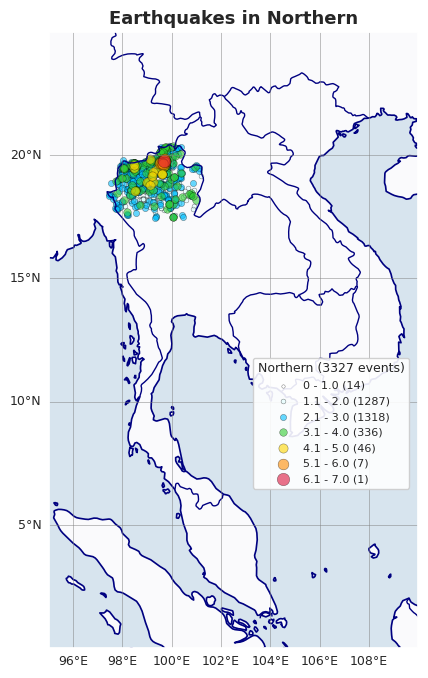

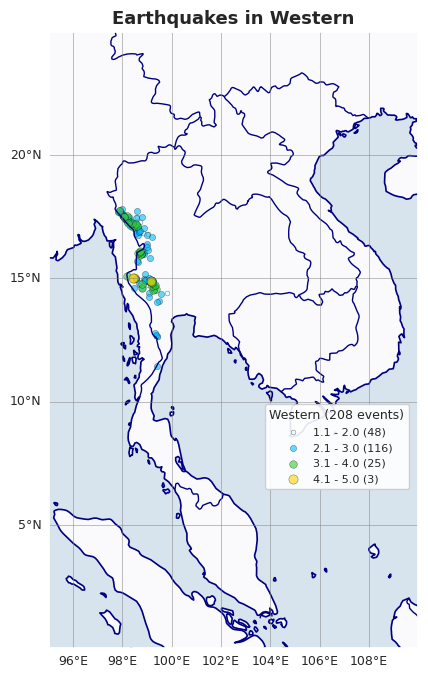

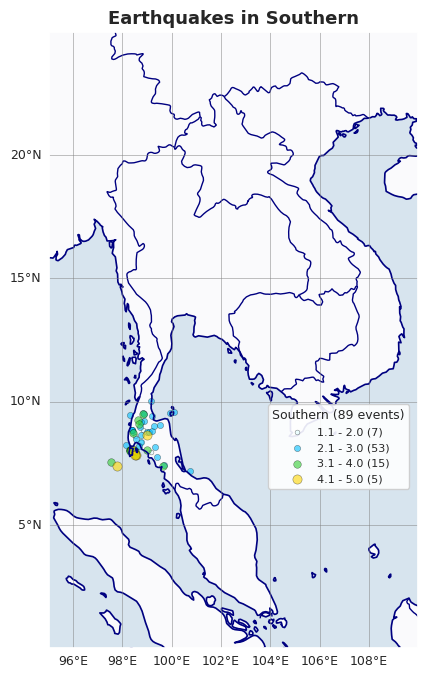

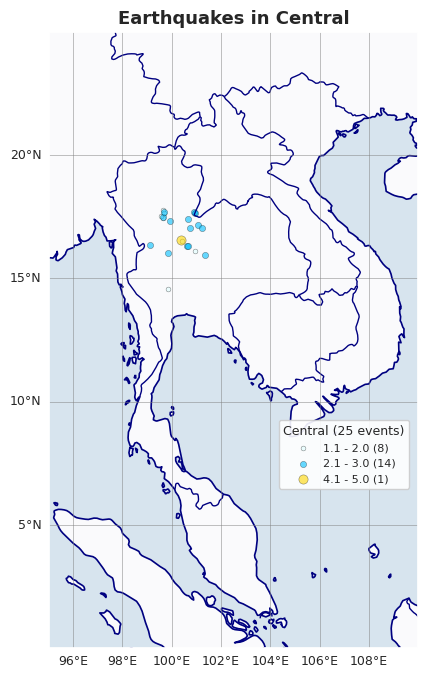

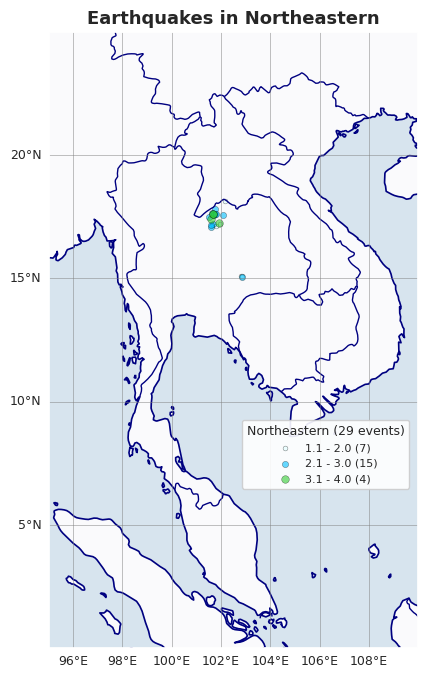

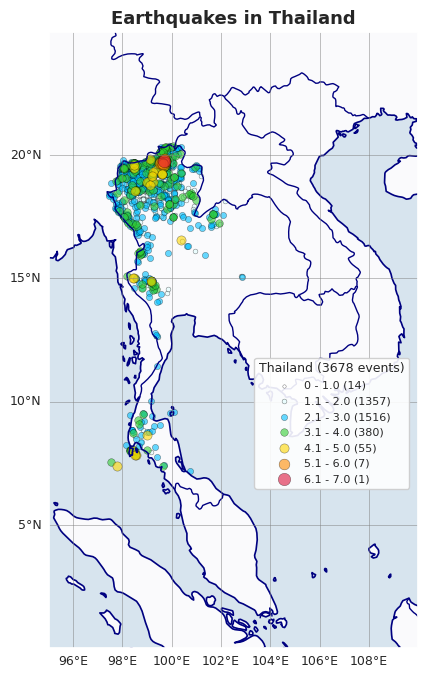

In [23]:
# Plot by Country : In progress

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np


df = df_eq.copy()
# === Function plot per region ===
def plot_region(region_name, df_region):
    lat_all = df_region["lat"].values
    lon_all = df_region["long"].values
    mag_all = df_region["mag"].values

    # Filter in SEA
    mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
    lat_filtered = lat_all[mask]
    lon_filtered = lon_all[mask]
    mag_filtered = mag_all[mask]

    # Create Map
    #fig = plt.figure(figsize=(8, 10))
    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([95, 110, 0, 25], crs=ccrs.PlateCarree())

    # Add Geo features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
    ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # Colormap magnitude
    colors_map = {
        (0, 1.0):   ('white', 3),
        (1.1, 2.0): ('lightcyan', 6),
        (2.1, 3.0): ('deepskyblue', 10),
        (3.1, 4.0): ('limegreen', 15),
        (4.1, 5.0): ('gold', 22),
        (5.1, 6.0): ('darkorange', 30),
        (6.1, 7.0): ('crimson', 40),
        (7.1, 8.0): ('darkred', 55),
        (8.1, 9.0): ('indigo', 75)
    }

    # Scatter points
    for (min_mag, max_mag), (color, size) in colors_map.items():
        mask_mag = (mag_filtered >= min_mag) & (mag_filtered < max_mag)
        if np.any(mask_mag):
            count = np.sum(mask_mag)
            ax.scatter(lon_filtered[mask_mag], lat_filtered[mask_mag],
                       c=color, s=size*2, alpha=0.6,
                       edgecolor='black', linewidth=0.3,
                       transform=ccrs.PlateCarree(),
                       label=f'{min_mag} - {max_mag} ({count})')

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Legend
    legend = ax.legend(title=f'{region_name} ({len(mag_filtered)} events)',
                       loc='lower right', fontsize=8, title_fontsize=9,
                       bbox_to_anchor=(0.99, 0.25))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    ax.set_title(f"Earthquakes in {region_name}", fontsize=13, fontweight='bold')
    plt.show()

# === Drop NaN in Region ===
df_eq = df_eq.dropna(subset=["region"])

# === Loop plot per region ===
regions = df_eq["region"].unique()

for reg in regions:
    df_region = df_eq[df_eq["region"] == reg]
    plot_region(reg, df_region)


# === Drop NaN in Country ===
df_eq = df_eq.dropna(subset=["country"])

# === Loop plot per Country ===
countrys = df_eq["country"].unique()

for reg in countrys:
    df_country = df_eq[df_eq["country"] == reg]
    plot_region(reg, df_country)


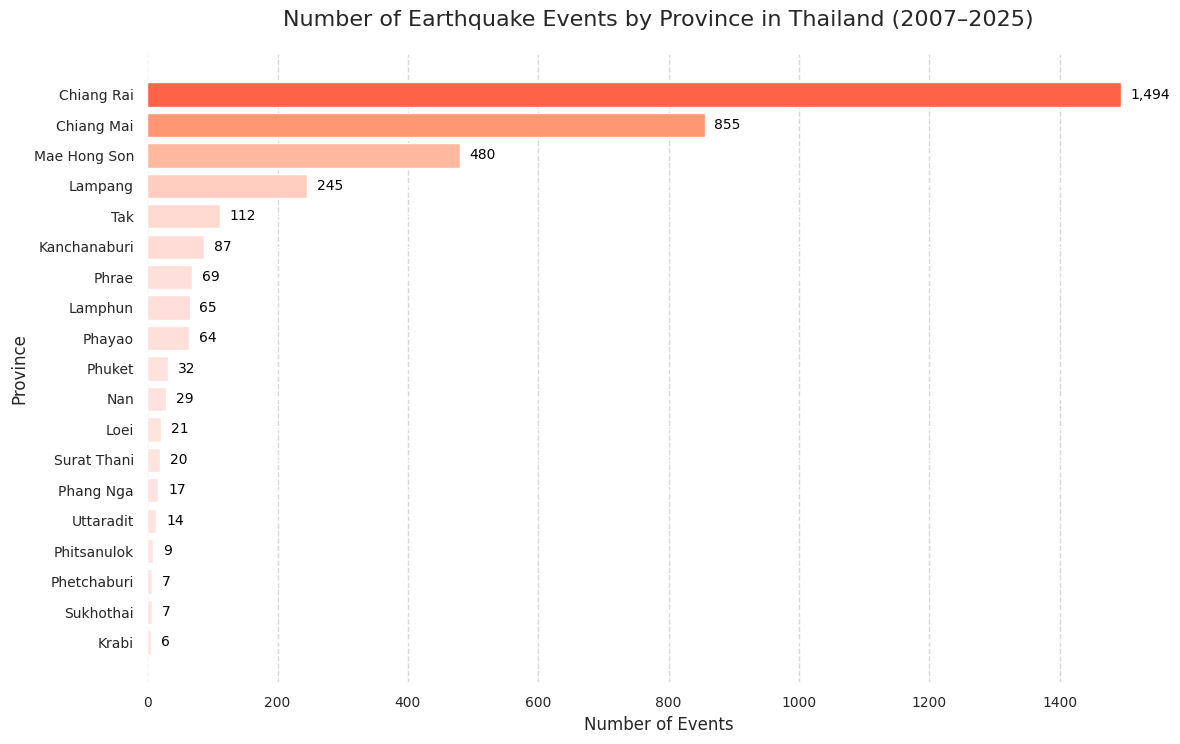

In [35]:

# เตรียมข้อมูล
province_counts = df[df['COUNTRY'].str.strip().str.lower() == 'thailand']['PROVINCE'].value_counts()
province_counts = province_counts[province_counts > 5].sort_values(ascending=True)

# สร้าง colormap ไล่เฉดสีจาก tomato ถึง lightsalmon
custom_cmap = mcolors.LinearSegmentedColormap.from_list("salmon_gradient", ["mistyrose","lightsalmon","tomato"])


# Normalize ค่าจำนวนเหตุการณ์เพื่อใช้กับ colormap
norm = plt.Normalize(province_counts.min(), province_counts.max())
colors = custom_cmap(norm(province_counts.values))

# ปรับขนาดกราฟตามจำนวนจังหวัด
height = 0.4 * len(province_counts)
fig, ax = plt.subplots(figsize=(12, height))

# พล็อตกราฟแท่งแนวนอน
bars = ax.barh(province_counts.index, province_counts.values, color=colors)

# เพิ่มตัวเลขที่ปลายแท่ง
for bar in bars:
    width = bar.get_width()
    ax.text(width + province_counts.max()*0.01, bar.get_y() + bar.get_height() / 2,
            f'{int(width):,}',
            va='center', ha='left',
            fontsize=10, color='black')


# ปรับพื้นหลังและกริด
ax.set_facecolor('white')
ax.grid(True, axis='x', linestyle='--', color='gray', alpha=0.3)

# ปรับแกนและข้อความ
ax.set_title('Number of Earthquake Events by Province in Thailand (2007–2025)', fontsize=16, pad=20)
ax.set_xlabel('Number of Events')
ax.set_ylabel('Province')
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()


# PATH IV

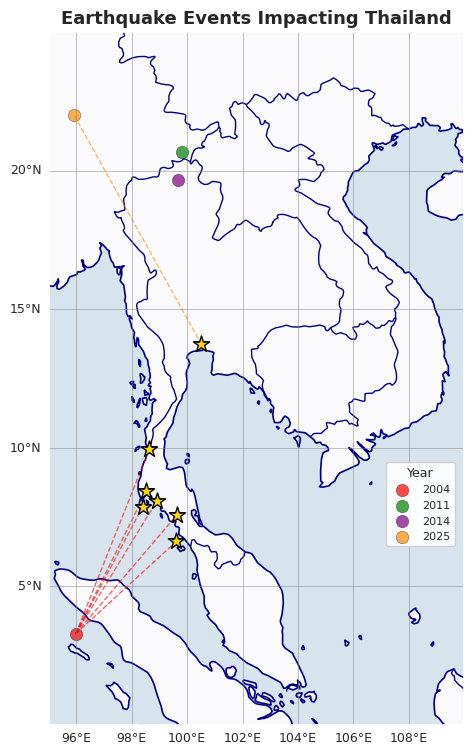

In [37]:

# =========================
# โหลดไฟล์ Excel
# =========================
url = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/disaster_emdat.xlsx"
df = pd.read_excel(url, sheet_name="Data_Earthquake")

# =========================
# Filter: Thailand + Earthquake
# =========================
df_eq = df[(df['Country']=='Thailand') & (df['disaster type']=='Earthquake')].copy()
df_eq = df_eq.dropna(subset=['region'])

# =========================
# จุดเป้าหมายแต่ละสี (ไม่มีเชียงรายแล้ว)
# =========================
targets_map = {
    'darkorange': [(13.7563, 100.5018)],  # Bangkok
    'red': [  # ภาคใต้ 6 จังหวัด
        (8.0863, 98.9063),   # Krabi
        (8.4500, 98.5250),   # Phangnga
        (7.8804, 98.3923),   # Phuket
        (9.9583, 98.6342),   # Ranong
        (6.6231, 99.6060),   # Satun
        (7.5667, 99.6167)    # Trang
    ]
}

# =========================
# ฟังก์ชัน Interactive Map per Region with colored lines
# =========================
def plot_region_interactive_lines(region_name, df_region):
    lat_all = df_region['latitude'].values
    lon_all = df_region['longitude'].values
    year_all = df_region['Start_Year'].values
    disno_all = df_region['disno.'].values
    mag_all = df_region['magnitude'].values
    mmi_all = df_region['mmi'].values
    deaths_all = df_region['Total_Deaths'].values
    damage_all = df_region['Total_Damage'].values

    mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
    lat_filtered = lat_all[mask]
    lon_filtered = lon_all[mask]
    year_filtered = year_all[mask]
    disno_filtered = disno_all[mask]
    mag_filtered = mag_all[mask]
    mmi_filtered = mmi_all[mask]
    deaths_filtered = deaths_all[mask]
    damage_filtered = damage_all[mask]

    # สีตาม 4 ปีแรก
    unique_years = sorted(np.unique(year_filtered))[:4]
    colors = ['red','green','purple','darkorange']
    color_map = {y:c for y,c in zip(unique_years, colors)}

    fig = plt.figure(figsize=(7,9))
    ax = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
    ax.set_extent([95,110,0,25], ccrs.PlateCarree())

    # Add geo features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
    ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # =========================
    # วาด scatter จุดเป้าหมาย (Bangkok + ภาคใต้) เท่านั้น
    # =========================
    for color, targets in targets_map.items():
        for lat_t, lon_t in targets:
            ax.scatter(lon_t, lat_t, c='gold', s=150, marker='*', edgecolor='black',
                       transform=ccrs.PlateCarree(), zorder=5)

    # =========================
    # วาด scatter เหตุการณ์จริง + เส้นไปยังเป้าหมาย
    # =========================
    scatter_points = []
    for y in unique_years:
        mask_year = year_filtered == y
        sc = ax.scatter(lon_filtered[mask_year], lat_filtered[mask_year],
                        c=color_map[y], s=80, alpha=0.7,
                        transform=ccrs.PlateCarree(),
                        edgecolor='black', linewidth=0.3,
                        label=f'{y}')
        scatter_points.append(sc)

        # วาดเส้นจากเหตุการณ์ไปยัง target (เฉพาะ Bangkok + ภาคใต้)
        color = color_map[y]
        if color not in targets_map:
            continue
        for lon_pt, lat_pt in zip(lon_filtered[mask_year], lat_filtered[mask_year]):
            for lat_t, lon_t in targets_map[color]:
                ax.plot([lon_pt, lon_t], [lat_pt, lat_t],
                        color=color, linestyle='--', linewidth=1,
                        transform=ccrs.PlateCarree(), alpha=0.6)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size':9}
    gl.ylabel_style = {'size':9}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Legend
    legend = ax.legend(title=f'Year', loc='lower right', fontsize=8, title_fontsize=9,
                       bbox_to_anchor=(0.99,0.25))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    ax.set_title(f"Earthquake Events Impacting Thailand", fontsize=13, fontweight='bold')

    # =========================
    # Interactive hover
    # =========================
    cursor = mplcursors.cursor(scatter_points, hover=True)
    @cursor.connect("add")
    def on_add(sel):
        index = sel.target.index
        sel.annotation.set_text(
            f"Disno: {disno_filtered[index]}\n"
            f"Year: {year_filtered[index]}\n"
            f"Magnitude: {mag_filtered[index]}\n"
            f"MMI: {mmi_filtered[index]}\n"
            f"Deaths: {deaths_filtered[index]}\n"
            f"Damage: {damage_filtered[index]}"
        )
        sel.annotation.get_bbox_patch().set(alpha=0.8, facecolor='yellow')

    plt.show()

# =========================
# Loop per region
# =========================
regions = df_eq['region'].unique()
for reg in regions:
    df_region = df_eq[df_eq['region']==reg]
    plot_region_interactive_lines(reg, df_region)


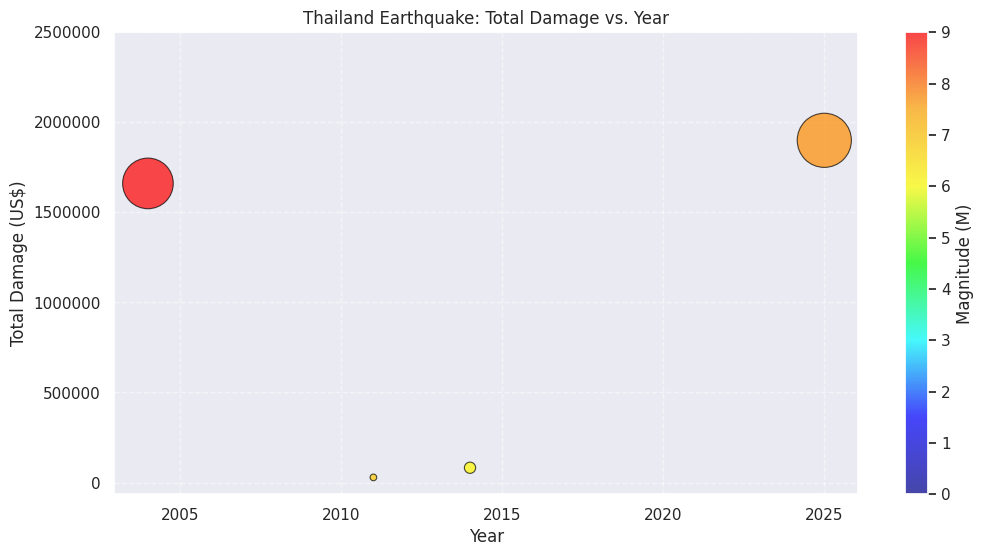

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter

# =========================
# โหลดไฟล์ Excel
# =========================
url = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/disaster_emdat.xlsx"
df = pd.read_excel(url, sheet_name="Data_Earthquake")

# Filter Thailand + Earthquake
df_eq = df[(df['Country']=='Thailand') & (df['disaster type']=='Earthquake')].copy()
df_eq = df_eq.dropna(subset=['magnitude','depth','Total_Damage','mmi'])

# แปลงคอลัมน์เป็นตัวเลข
numeric_cols = ['Total_Deaths','Total_Affected','Total_Damage','magnitude','mmi','depth']
for col in numeric_cols:
    df_eq[col] = pd.to_numeric(df_eq[col], errors='coerce').fillna(0)

# แทนค่า Total_Damage ที่เป็น 0
df_eq['Total_Damage'] = df_eq['Total_Damage'].replace(0,1)
df_eq = df_eq.rename(columns={'Start_Year': 'Year'})

# =========================
# Bubble Size = Total Damage (Linear Scale)
# =========================
size_factor = 0.0001
df_eq['Bubble_Size'] = df_eq['Total_Damage'] * size_factor

# =========================
# Custom Colormap
# =========================
colors = [
    (0.0, "darkblue"),
    (0.2, "blue"),
    (0.4, "cyan"),
    (0.6, "lime"),
    (0.8, "yellow"),
    (0.9, "orange"),
    (1.0, "red")
]
custom_cmap = LinearSegmentedColormap.from_list("custom_scale", [c[1] for c in colors])

# =========================
# Plot
# =========================
plt.figure(figsize=(12, 6))

sc = plt.scatter(
    df_eq['Year'],
    df_eq['Total_Damage'],
    s=df_eq['Bubble_Size']*8,
    c=df_eq['magnitude'],
    cmap=custom_cmap,
    alpha=0.7,
    edgecolors="black",
    linewidth=0.8,
    vmin=0, vmax=9
)

# Colorbar Magnitude
cbar = plt.colorbar(sc)
cbar.set_label("Magnitude (M)")
cbar.set_ticks(range(0, 10))

# =========================
# แก้ไข Y-axis ให้เป็นตัวเลขปกติ + limit สูงสุด
# =========================
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.set_ylim(top=2500000)  # ✅ กำหนด Y-axis สูงสุด 2,000,000

plt.xlabel("Year")
plt.ylabel("Total Damage (US$)")
plt.title("Thailand Earthquake: Total Damage vs. Year")

plt.grid(True, ls="--", alpha=0.5)
plt.show()
